### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [244]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [245]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('../data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [246]:
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [247]:
# Yayyy, no missing data!
df.isna().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SeasonEnd  835 non-null    int64 
 1   Team       835 non-null    object
 2   Playoffs   835 non-null    int64 
 3   W          835 non-null    int64 
 4   PTS        835 non-null    int64 
 5   oppPTS     835 non-null    int64 
 6   FG         835 non-null    int64 
 7   FGA        835 non-null    int64 
 8   2P         835 non-null    int64 
 9   2PA        835 non-null    int64 
 10  3P         835 non-null    int64 
 11  3PA        835 non-null    int64 
 12  FT         835 non-null    int64 
 13  FTA        835 non-null    int64 
 14  ORB        835 non-null    int64 
 15  DRB        835 non-null    int64 
 16  AST        835 non-null    int64 
 17  STL        835 non-null    int64 
 18  BLK        835 non-null    int64 
 19  TOV        835 non-null    int64 
dtypes: int64(19), object(1)
memory u

#### Check for Duplicates

In [249]:
# Check for Duplicates
df[df.duplicated()]

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV


#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [250]:
def inspect_dataframe(input_df):
    print("*"*80)

    print(f"Shape: {input_df.shape}")
    print("*"*80)

    # print("Data preview:")
    # print(input_df.head())
    # print("*"*80)

    # print("Column information:")
    # print(input_df.info())
    # print("*"*80)

    # print("Descriptive Statistics:")
    # print(input_df.describe())
    # print("*"*80)

    print("Missing Values:")
    print(input_df.isna().sum())
    print("*"*80)

    print("Duplicated rows:", input_df.duplicated().sum())
    
    print("*"*80)


In [251]:
inspect_dataframe(df)

********************************************************************************
Shape: (835, 20)
********************************************************************************
Missing Values:
SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64
********************************************************************************
Duplicated rows: 0
********************************************************************************


#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

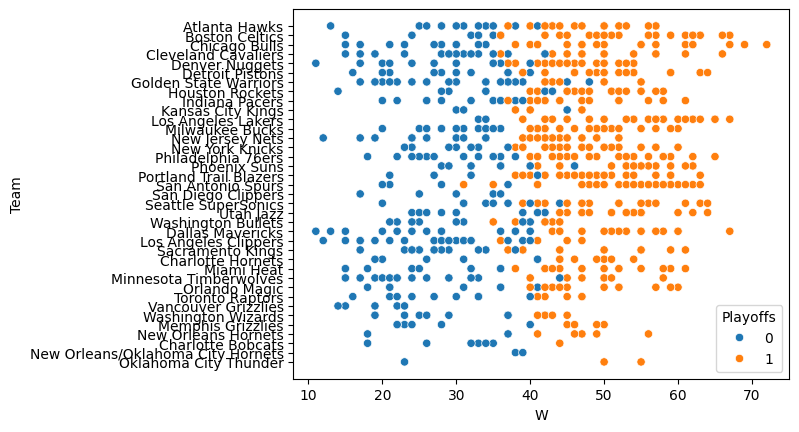

In [252]:
sns.scatterplot(df, x="W", y="Team", hue="Playoffs")
plt.show()

# roundabout 45+ wins

#### Take a rough estimate, and now use that moving forward.  



In [253]:
WINS_NEED_TO_MAKE_PLAYOFFS = 45

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


In [254]:
def create_and_summarize_model(df, ivs, dv):
    df = df.copy()
    
    X = df[ivs]
    y = df[dv]

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    y_hat = model.predict(X)
    calculated_rmse = rmse(y, y_hat)
    print(f"Average dv value: {y.mean()}")
    print(f"Root mean squared error: {round(calculated_rmse, 4)}")

    model_eval = model.summary2()
    print(model_eval)

    return model

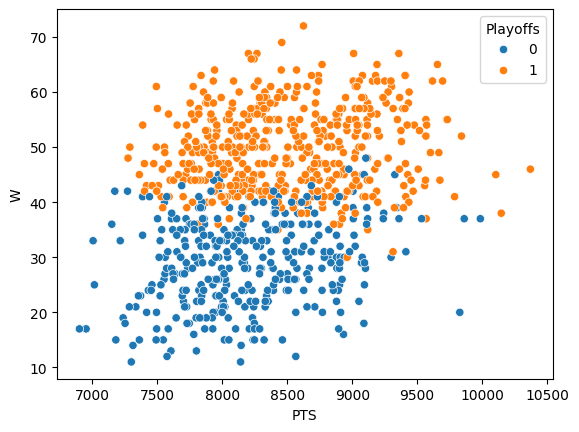

In [255]:
# there is not a strong linear relationship btw PTS and W
# therefore, this situation is unlike the moneyball project where 
# 1. winning 95+ games was correlated with a high chance of making it to the playoffs
# 2. the run difference was found to be linearly related to wins with a high r^2
# 3. maximizing the run difference, and therefore the scored runs, led to high chances of winning a lot
# 4. OBP and SLG were found to be good predictors of scored runs, with OBP being strongest.
# So, increasing OBP increased scored runs -> increased run difference -> increased wins -> increased likelihood of making it to the playoffs

# This chain relationship does not seem to be present in the NBA dataset
# The weak link / break in the chain is the lack of a single strong linear predictor of wins (point 2 above )
sns.scatterplot(df, x="PTS", y="W", hue="Playoffs")
plt.show()

In [256]:
target = 'W'
potential_predictor = ['PTS']
model = create_and_summarize_model(df, potential_predictor, target)

Average dv value: 41.0
Root mean squared error: 12.1514
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.088    
Dependent Variable: W                AIC:                6544.3570
Date:               2025-10-30 04:51 BIC:                6553.8119
No. Observations:   835              Log-Likelihood:     -3270.2  
Df Model:           1                F-statistic:        81.68    
Df Residuals:       833              Prob (F-statistic): 1.10e-18 
R-squared:          0.089            Scale:              148.01   
--------------------------------------------------------------------
          Coef.     Std.Err.      t      P>|t|     [0.025     0.975]
--------------------------------------------------------------------
const    -13.8463     6.0833   -2.2761   0.0231   -25.7866   -1.9059
PTS        0.0066     0.0007    9.0376   0.0000     0.0051    0.0080
------------------------------------------------------------------
Omnibus:      

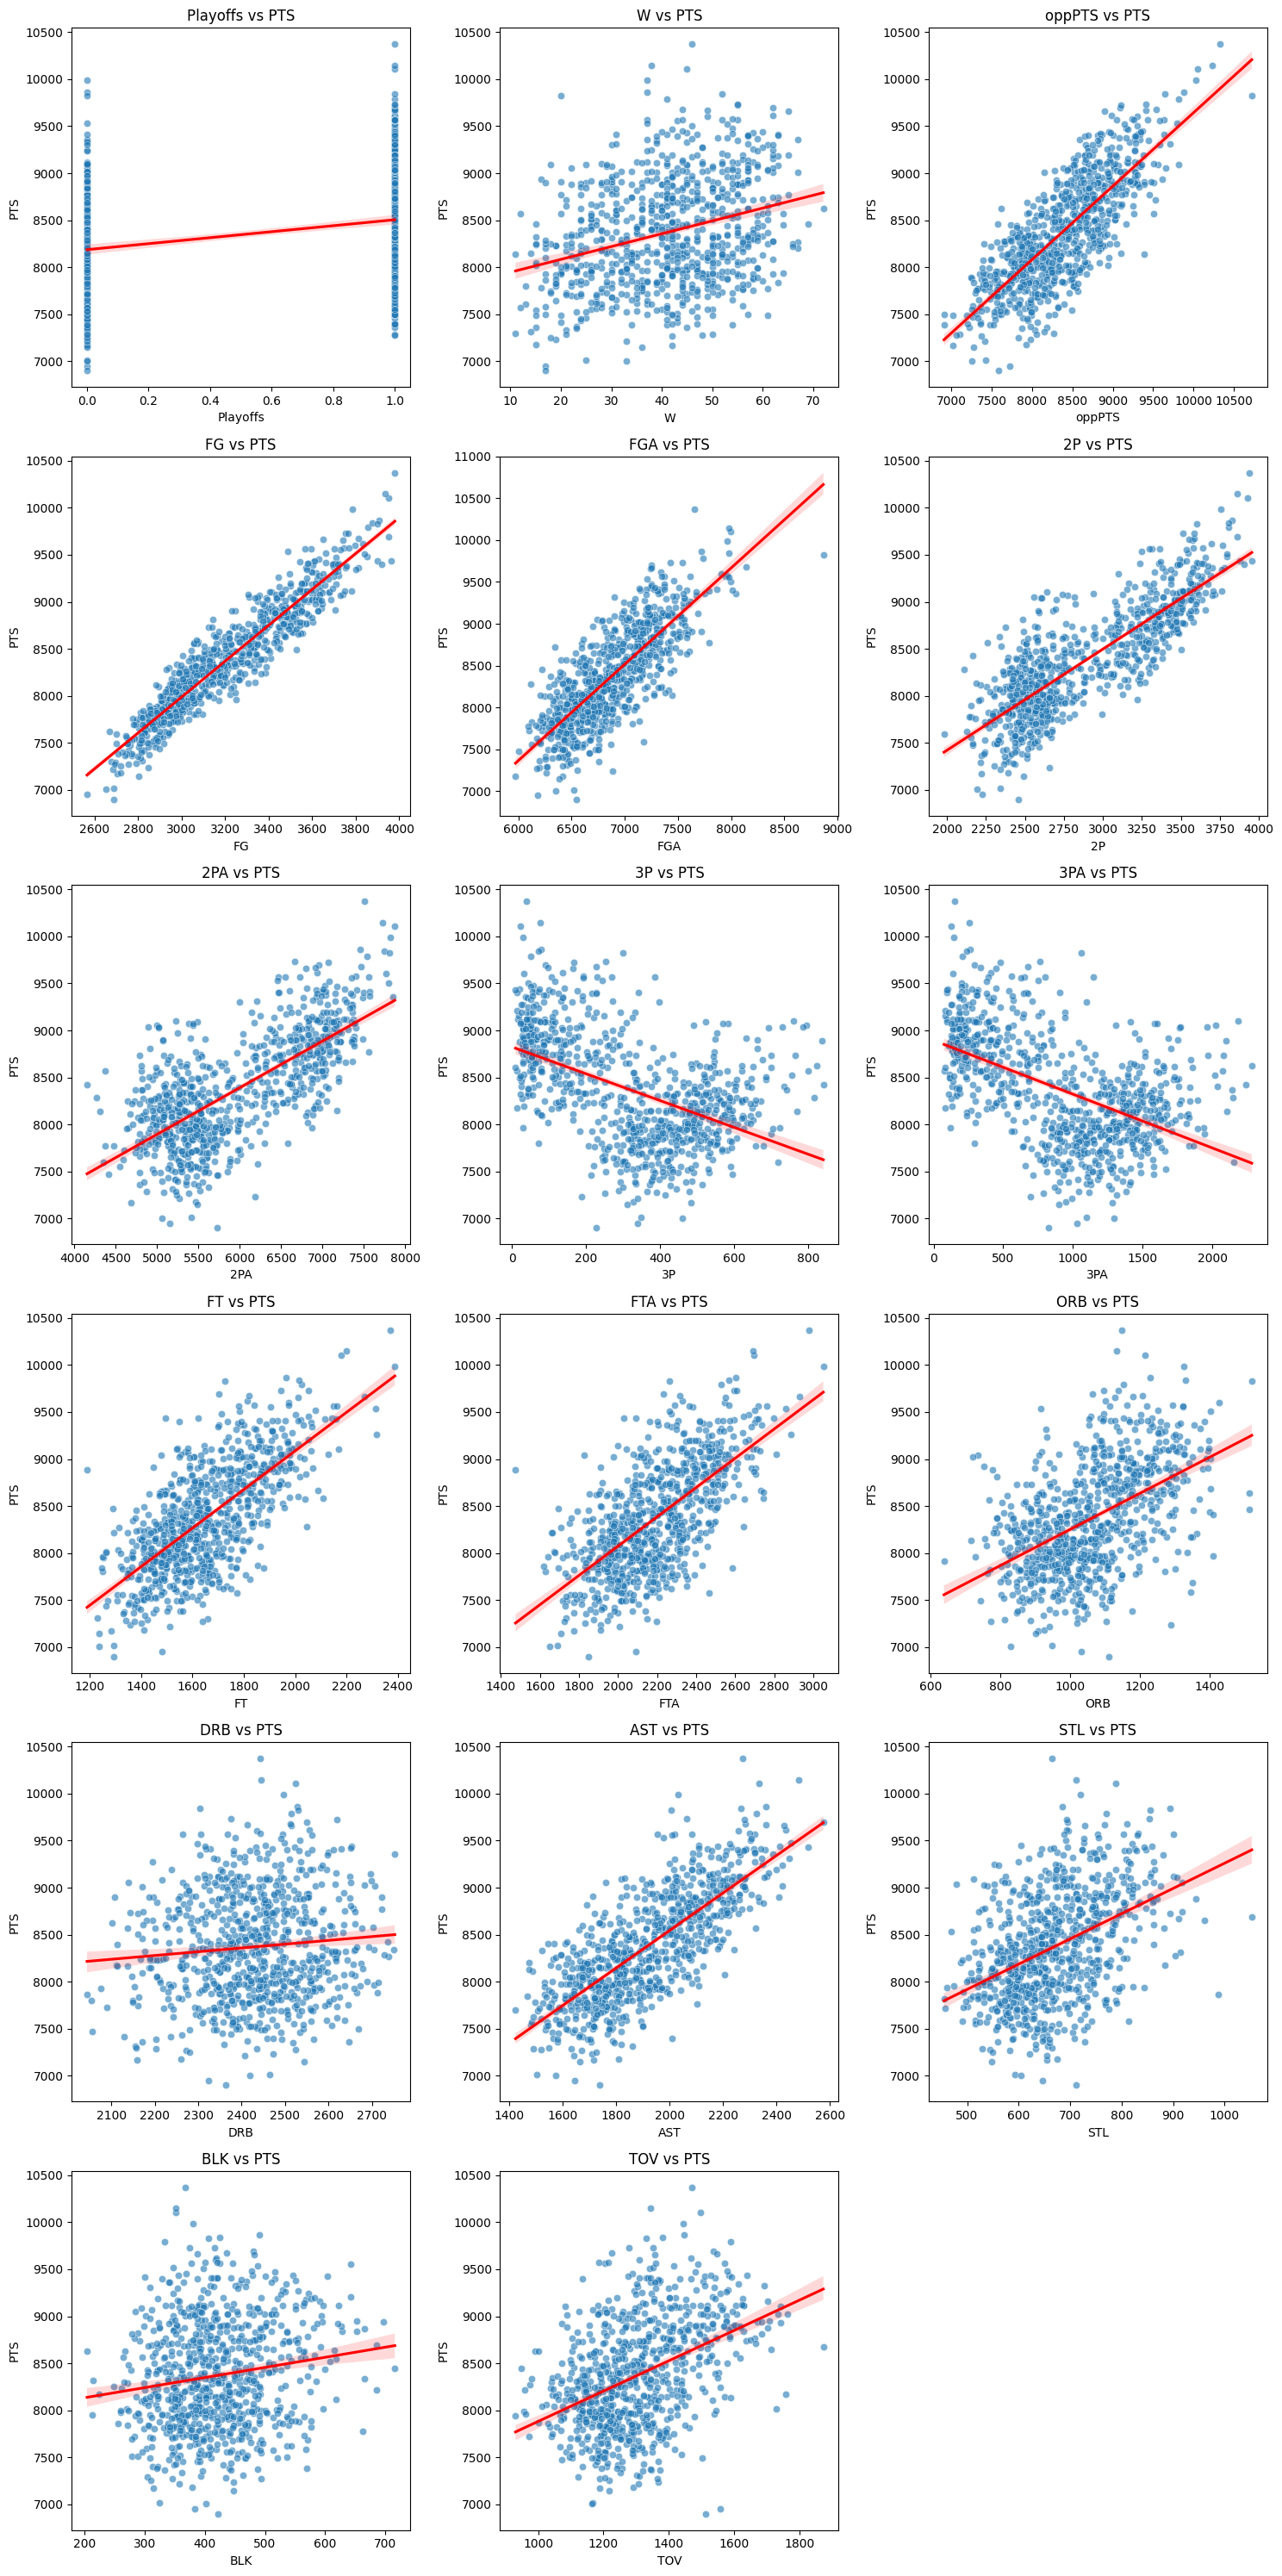

In [257]:
# Code adapted from lecture
# Set up figure and axes grid
dv = "PTS"

ivs = list(df.columns)
ivs.remove("SeasonEnd")
ivs.remove("Team")
ivs.remove("PTS")

n = len(ivs)

cols = 3  # you can change to 2 if you want fewer per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, var in enumerate(ivs):
    
    # Create a jointplot, but draw it on a custom axis
    sns.scatterplot(x=df[var], y=df[dv], ax=axes[i], alpha=0.6)

    # regression plot (aka the red line)
    sns.regplot(x=df[var], y=df[dv], ax=axes[i], scatter=False, color='red')

    #putting the plot in the subplot
    axes[i].set_title(f'{var} vs {dv}')

# Hide empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [258]:
# Goal: Build a Linear Regression model that predicts score given various basketball statistics
ivs = ['oppPTS', 'FGA', '2PA', '3PA',  'FTA', 'ORB', 'AST']
model = create_and_summarize_model(df, ivs, dv)

Average dv value: 8370.239520958085
Root mean squared error: 184.2971
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.899     
Dependent Variable: PTS              AIC:                11095.2642
Date:               2025-10-30 04:51 BIC:                11128.3562
No. Observations:   835              Log-Likelihood:     -5540.6   
Df Model:           6                F-statistic:        1232.     
Df Residuals:       828              Prob (F-statistic): 0.00      
R-squared:          0.899            Scale:              34253.    
-------------------------------------------------------------------
            Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
-------------------------------------------------------------------
const     -1960.8672 164.8010 -11.8984 0.0000 -2284.3441 -1637.3903
oppPTS        0.0712   0.0235   3.0260 0.0026     0.0250     0.1174
FGA           0.7050   0.0295  23.9037 0.0000     0.6471     0.7

In [259]:
df[ivs].corr().round(4)

,oppPTS,FGA,2PA,3PA,FTA,ORB,AST
oppPTS,1.0000,0.8309,0.7565,-0.5633,0.5372,0.5519,0.5426
FGA,0.8309,1.0000,0.8649,-0.6056,0.3821,0.7375,0.6291
2PA,0.7565,0.8649,1.0000,-0.9232,0.5238,0.7656,0.6777
3PA,-0.5633,-0.6056,-0.9232,1.0000,-0.5378,-0.6492,-0.5928
FTA,0.5372,0.3821,0.5238,-0.5378,1.0000,0.4746,0.4280
ORB,0.5519,0.7375,0.7656,-0.6492,0.4746,1.0000,0.4068
AST,0.5426,0.6291,0.6777,-0.5928,0.4280,0.4068,1.0000


In [260]:
ivs = ['2PA', 'FTA', 'AST']
model = create_and_summarize_model(df, ivs, dv)

Average dv value: 8370.239520958085
Root mean squared error: 301.0026
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.730     
Dependent Variable: PTS              AIC:                11908.5158
Date:               2025-10-30 04:51 BIC:                11927.4255
No. Observations:   835              Log-Likelihood:     -5950.3   
Df Model:           3                F-statistic:        753.9     
Df Residuals:       831              Prob (F-statistic): 1.40e-236 
R-squared:          0.731            Scale:              91039.    
--------------------------------------------------------------------
            Coef.    Std.Err.     t     P>|t|     [0.025     0.975] 
--------------------------------------------------------------------
const     3347.5788  109.3023  30.6268  0.0000  3133.0378  3562.1198
2PA          0.1462    0.0183   7.9984  0.0000     0.1103     0.1820
FTA          0.8176    0.0505  16.1872  0.0000     0.7185  

In [261]:
ivs = ['FGA', '3PA',  'FTA', 'ORB', 'AST']
model = create_and_summarize_model(df, ivs, dv)

Average dv value: 8370.239520958085
Root mean squared error: 185.3134
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.898     
Dependent Variable: PTS              AIC:                11102.4479
Date:               2025-10-30 04:51 BIC:                11130.8125
No. Observations:   835              Log-Likelihood:     -5545.2   
Df Model:           5                F-statistic:        1462.     
Df Residuals:       829              Prob (F-statistic): 0.00      
R-squared:          0.898            Scale:              34590.    
-------------------------------------------------------------------
            Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
-------------------------------------------------------------------
const     -2039.2852 163.5495 -12.4689 0.0000 -2360.3051 -1718.2653
FGA           1.0454   0.0283  36.8795 0.0000     0.9898     1.1011
3PA           0.2211   0.0189  11.6926 0.0000     0.1840     0.2

In [262]:
ivs = ['FGA', '3PA', 'ORB', 'AST']
model = create_and_summarize_model(df, ivs, dv)

Average dv value: 8370.239520958085
Root mean squared error: 288.5253
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.752     
Dependent Variable: PTS              AIC:                11839.8146
Date:               2025-10-30 04:51 BIC:                11863.4517
No. Observations:   835              Log-Likelihood:     -5914.9   
Df Model:           4                F-statistic:        633.0     
Df Residuals:       830              Prob (F-statistic): 2.37e-250 
R-squared:          0.753            Scale:              83748.    
---------------------------------------------------------------------
         Coef.     Std.Err.      t      P>|t|      [0.025     0.975] 
---------------------------------------------------------------------
const   247.1980   232.4685    1.0634   0.2879   -209.0973   703.4933
FGA       0.9208     0.0437   21.0494   0.0000      0.8350     1.0067
3PA       0.0625     0.0285    2.1888   0.0289      0.

In [263]:
# Best model in terms of r^2 score where coefficients make sense
# increasing assists and attempted free throws by 10, increases the points scored by 10 each;
# increasing attempted field goals by 10, increases points scores by 8;
# increasing attempted 3 pointers by 10, increases points scored by 3;
ivs = ['FGA', '3PA',  'FTA', 'AST']
model = create_and_summarize_model(df, ivs, dv)

Average dv value: 8370.239520958085
Root mean squared error: 205.7919
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.874     
Dependent Variable: PTS              AIC:                11275.4930
Date:               2025-10-30 04:51 BIC:                11299.1301
No. Observations:   835              Log-Likelihood:     -5632.7   
Df Model:           4                F-statistic:        1445.     
Df Residuals:       830              Prob (F-statistic): 0.00      
R-squared:          0.874            Scale:              42605.    
--------------------------------------------------------------------
         Coef.     Std.Err.     t     P>|t|     [0.025      0.975]  
--------------------------------------------------------------------
const  -1646.4006  178.7843  -9.2089  0.0000  -1997.3230  -1295.4781
FGA        0.8013    0.0247  32.4400  0.0000      0.7528      0.8498
3PA        0.3165    0.0196  16.1810  0.0000      0.2781   

In [264]:
def predict_score(model, ivs, team, year):
    sample = df[(df["Team"] == team) & (df["SeasonEnd"] == year)]
    print(sample)

    # const, FGA, 3PA, FTA, AST  
    predicted = model.predict([1] + np.array(sample[ivs]).tolist()[0])[0]
    real = list(sample["PTS"])[0]
    print(f"Predicted score: {round(predicted, 0)}\nReal score: {round(real, 0)}\nError: {round(predicted - real, 2)}")

In [265]:
predict_score(model, ivs, "San Antonio Spurs", 2011)

     SeasonEnd               Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
831       2011  San Antonio Spurs         1  61  8502    8034  3148  6628   

       2P   2PA   3P   3PA    FT   FTA  ORB   DRB   AST  STL  BLK   TOV  
831  2463  4901  685  1727  1521  1984  829  2603  1836  602  372  1101  
Predicted score: 8142.0
Real score: 8502
Error: -360.28


In [266]:
predict_score(model, ivs, "San Antonio Spurs", 2010)

     SeasonEnd               Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
801       2010  San Antonio Spurs         1  50  8312    7895  3150  6659   

       2P   2PA   3P   3PA    FT   FTA  ORB   DRB   AST  STL  BLK   TOV  
801  2596  5112  554  1547  1458  1969  887  2621  1829  516  381  1116  
Predicted score: 8087.0
Real score: 8312
Error: -224.94


In [267]:
predict_score(model, ivs, "San Antonio Spurs", 2000)

     SeasonEnd               Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
503       2000  San Antonio Spurs         1  53  7886    7399  2952  6393   

       2P   2PA   3P  3PA    FT   FTA  ORB   DRB   AST  STL  BLK   TOV  
503  2622  5511  330  882  1652  2214  927  2666  1819  614  551  1233  
Predicted score: 7901.0
Real score: 7886
Error: 15.39
